### Alzheimer Disease Diagnosis ML Pipeline

 Goal: Predict the risk/likelihood of a patient being diagnosed with Alzheimer's disease using a patients health and cognitive data.   
 Purpose: As early diagnosis is difficult due to symptoms of Alzheimer's appearing gradually and resemble aging, this project aims to better predict early signs in order for a faster and effective treatment of the patient.  
 Problem Type: Binary Classification -> Diagnosis = 1 (Alzheimer's Present) vs. Diagnosis = 0 (Alzheimer's Absent)

### Step 1: Import Libraries

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report,
    ConfusionMatrixDisplay
)
from sklearn.inspection import permutation_importance
import xgboost as xgb

# styles
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
PALETTE = {'0 – No Alzheimer\'s': '#4C9BE8', '1 – Alzheimer\'s': '#E8694C'}
COLORS  = ['#4C9BE8', '#E8694C', '#5DBB7A']
np.random.seed(42)

print('Libraries loaded.')

Libraries loaded.


## Step 2: Load Dataset

In [3]:
data = pd.read_csv("../datasets/Alzheimers_disease_data.csv")
print('Dataset loaded.')
print(f"Dataset shape: {data.shape}") 
data.head()

Dataset loaded.
Dataset shape: (2149, 35)


,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,...,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,...,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,...,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,...,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,...,0,0,0.014691,0,0,1,1,0,0,XXXConfid


## Step 3: Exploratory Data Analysis (EDA)

In [4]:
print("Data Types:")
data.dtypes

Data Types:


PatientID                      int64
Age                            int64
Gender                         int64
Ethnicity                      int64
EducationLevel                 int64
BMI                          float64
Smoking                        int64
AlcoholConsumption           float64
PhysicalActivity             float64
DietQuality                  float64
SleepQuality                 float64
FamilyHistoryAlzheimers        int64
CardiovascularDisease          int64
Diabetes                       int64
Depression                     int64
HeadInjury                     int64
Hypertension                   int64
SystolicBP                     int64
DiastolicBP                    int64
CholesterolTotal             float64
CholesterolLDL               float64
CholesterolHDL               float64
CholesterolTriglycerides     float64
MMSE                         float64
FunctionalAssessment         float64
MemoryComplaints               int64
BehavioralProblems             int64
A

In [5]:
print("Missing Values:")
data.isnull().sum()

Missing Values:


PatientID                    0
Age                          0
Gender                       0
Ethnicity                    0
EducationLevel               0
BMI                          0
Smoking                      0
AlcoholConsumption           0
PhysicalActivity             0
DietQuality                  0
SleepQuality                 0
FamilyHistoryAlzheimers      0
CardiovascularDisease        0
Diabetes                     0
Depression                   0
HeadInjury                   0
Hypertension                 0
SystolicBP                   0
DiastolicBP                  0
CholesterolTotal             0
CholesterolLDL               0
CholesterolHDL               0
CholesterolTriglycerides     0
MMSE                         0
FunctionalAssessment         0
MemoryComplaints             0
BehavioralProblems           0
ADL                          0
Confusion                    0
Disorientation               0
PersonalityChanges           0
DifficultyCompletingTasks    0
Forgetfu

In [6]:
print("Data Information:")
data.info()
print("\nDescriptive Statistics:")
data.describe()

Data Information:
<class 'pandas.DataFrame'>
RangeIndex: 2149 entries, 0 to 2148
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PatientID                  2149 non-null   int64  
 1   Age                        2149 non-null   int64  
 2   Gender                     2149 non-null   int64  
 3   Ethnicity                  2149 non-null   int64  
 4   EducationLevel             2149 non-null   int64  
 5   BMI                        2149 non-null   float64
 6   Smoking                    2149 non-null   int64  
 7   AlcoholConsumption         2149 non-null   float64
 8   PhysicalActivity           2149 non-null   float64
 9   DietQuality                2149 non-null   float64
 10  SleepQuality               2149 non-null   float64
 11  FamilyHistoryAlzheimers    2149 non-null   int64  
 12  CardiovascularDisease      2149 non-null   int64  
 13  Diabetes                   2149 non-null 

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis
count,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,...,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000
mean,5825.000000,74.908795,0.506282,0.697534,1.286645,27.655697,0.288506,10.039442,4.920202,4.993138,...,5.080055,0.208004,0.156817,4.982958,0.205212,0.158213,0.150768,0.158678,0.301536,0.353653
std,620.507185,8.990221,0.500077,0.996128,0.904527,7.217438,0.453173,5.757910,2.857191,2.909055,...,2.892743,0.405974,0.363713,2.949775,0.403950,0.365026,0.357906,0.365461,0.459032,0.478214
min,4751.000000,60.000000,0.000000,0.000000,0.000000,15.008851,0.000000,0.002003,0.003616,0.009385,...,0.000460,0.000000,0.000000,0.001288,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5288.000000,67.000000,0.000000,0.000000,1.000000,21.611408,0.000000,5.139810,2.570626,2.458455,...,2.566281,0.000000,0.000000,2.342836,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,5825.000000,75.000000,1.000000,0.000000,1.000000,27.823924,0.000000,9.934412,4.766424,5.076087,...,5.094439,0.000000,0.000000,5.038973,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,6362.000000,83.000000,1.000000,1.000000,2.000000,33.869778,1.000000,15.157931,7.427899,7.558625,...,7.546981,0.000000,0.000000,7.581490,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
max,6899.000000,90.000000,1.000000,3.000000,3.000000,39.992767,1.000000,19.989293,9.987429,9.998346,...,9.996467,1.000000,1.000000,9.999747,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


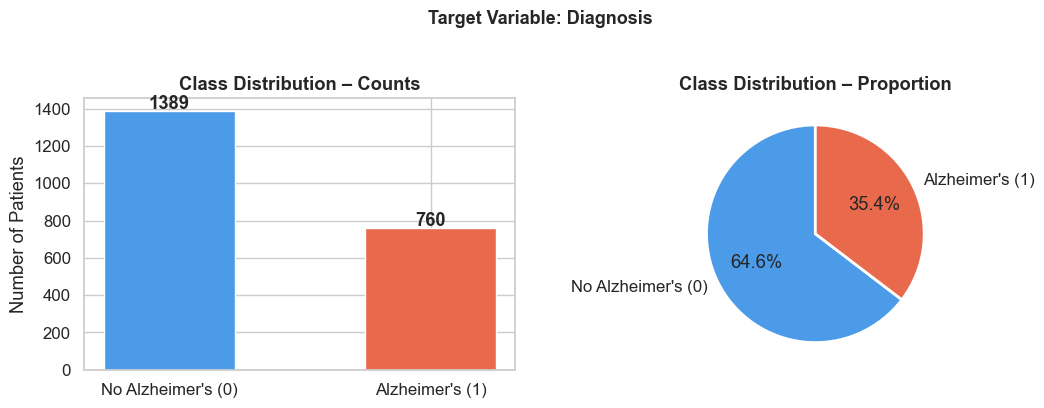

Class ratio (0:1) = 1.83 – Moderate imbalance


In [7]:
# Target Variable Distribution
counts = data['Diagnosis'].value_counts().sort_index()
labels = ["No Alzheimer's (0)", "Alzheimer's (1)"]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(labels, counts.values, color=COLORS[:2], edgecolor='white', width=0.5)
axes[0].set_title('Class Distribution – Counts', fontweight='bold')
axes[0].set_ylabel('Number of Patients')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=labels, colors=COLORS[:2],
            autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Class Distribution – Proportion', fontweight='bold')

plt.suptitle('Target Variable: Diagnosis', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

imbalance_ratio = counts[0] / counts[1]
print(f'Class ratio (0:1) = {imbalance_ratio:.2f} – Moderate imbalance')

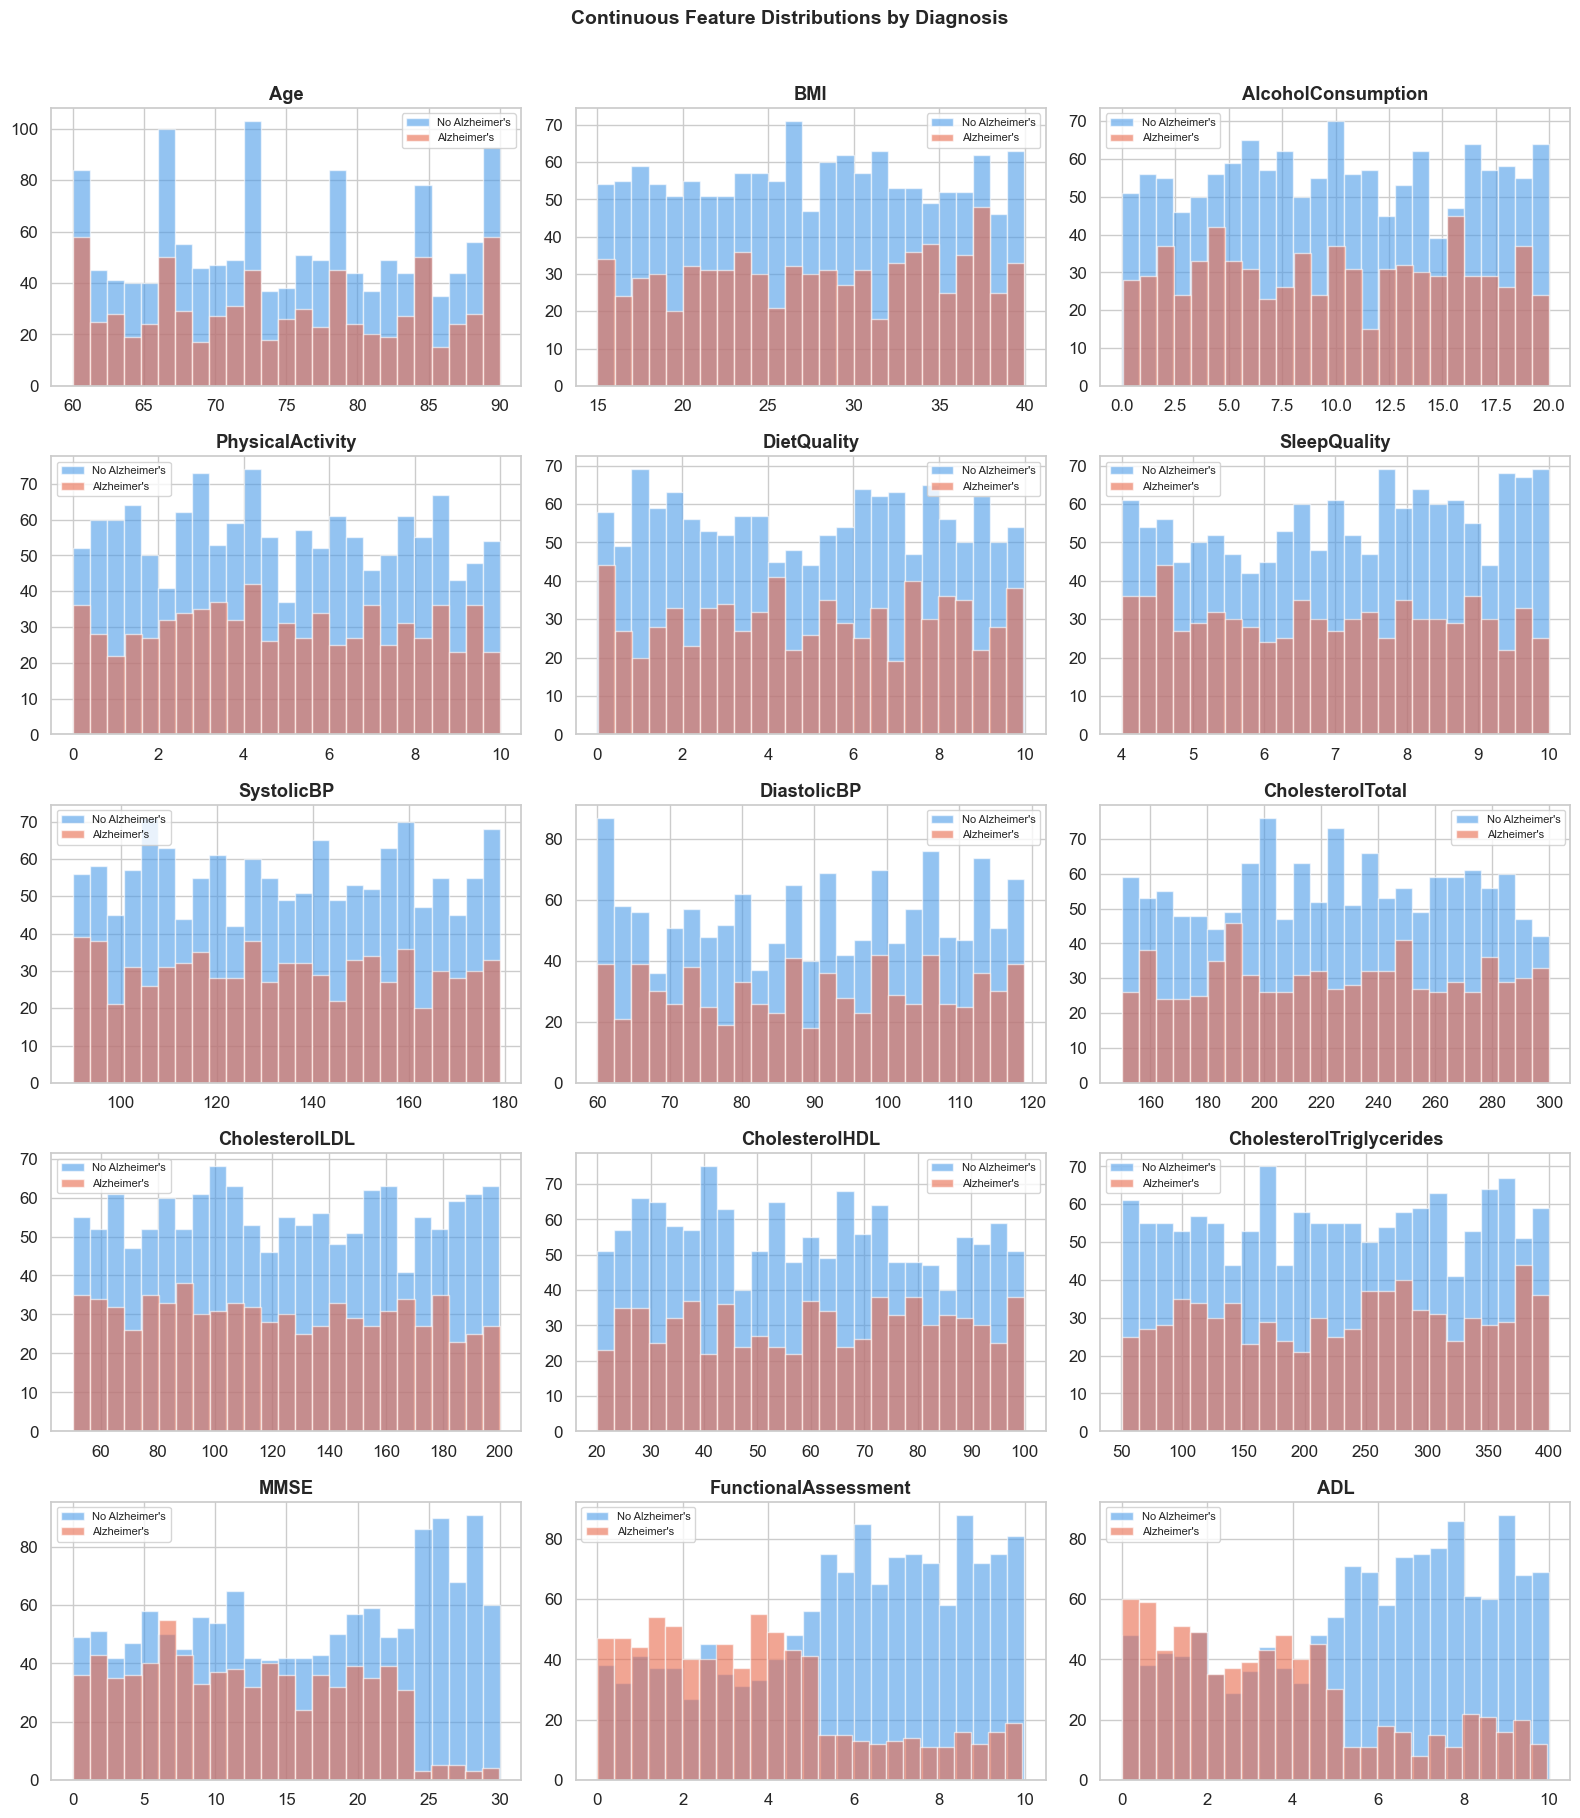

In [8]:
# Feature Distributions
continuous_cols = [
    'Age', 'BMI', 'AlcoholConsumption', 'PhysicalActivity',
    'DietQuality', 'SleepQuality', 'SystolicBP', 'DiastolicBP',
    'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL',
    'CholesterolTriglycerides', 'MMSE', 'FunctionalAssessment', 'ADL'
]

fig, axes = plt.subplots(5, 3, figsize=(16, 18))
axes = axes.flatten()

for i, col in enumerate(continuous_cols):
    for diag, color in zip([0, 1], COLORS[:2]):
        axes[i].hist(data.loc[data['Diagnosis'] == diag, col],
                     bins=25, alpha=0.6, color=color,
                     label=f"{'No ' if diag == 0 else ''}Alzheimer's")
    axes[i].set_title(col, fontweight='bold')
    axes[i].legend(fontsize=8)

plt.suptitle('Continuous Feature Distributions by Diagnosis', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

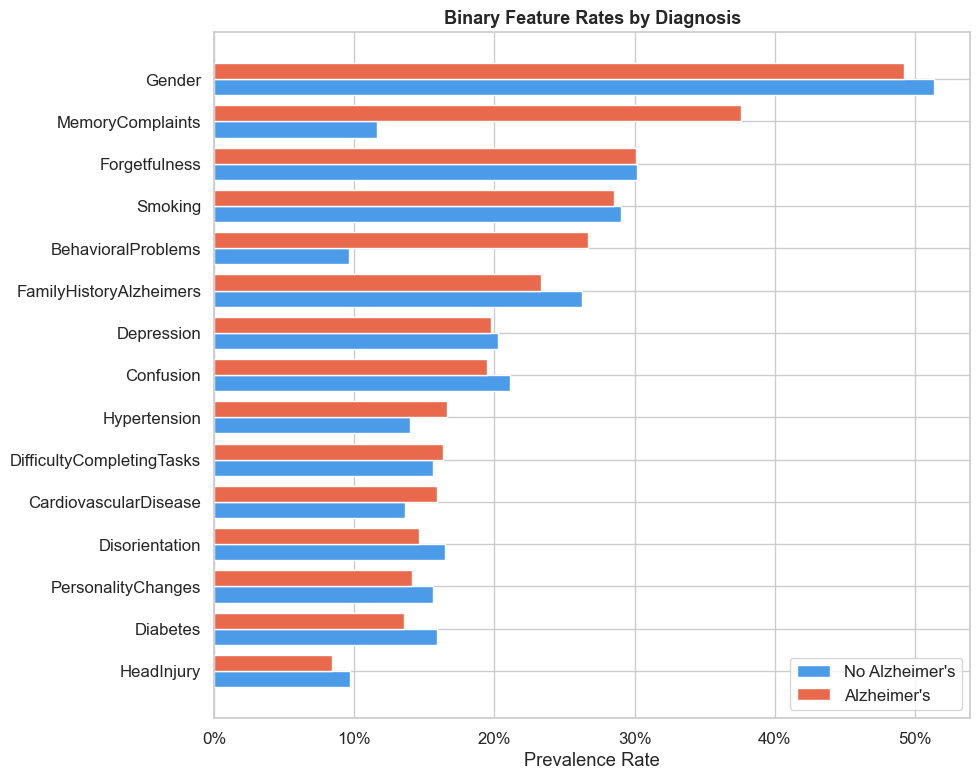

In [9]:
# ── Binary / Categorical Feature Rates ──────────────────────────────────
binary_cols = [
    'Gender', 'Smoking', 'FamilyHistoryAlzheimers', 'CardiovascularDisease',
    'Diabetes', 'Depression', 'HeadInjury', 'Hypertension',
    'MemoryComplaints', 'BehavioralProblems', 'Confusion',
    'Disorientation', 'PersonalityChanges', 'DifficultyCompletingTasks', 'Forgetfulness'
]

rates = (data.groupby('Diagnosis')[binary_cols]
         .mean()
         .T
         .rename(columns={0: "No Alzheimer's", 1: "Alzheimer's"}))

rates_sorted = rates.sort_values("Alzheimer's", ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
x = np.arange(len(rates_sorted))
width = 0.38
ax.barh(x - width/2, rates_sorted["No Alzheimer's"],  width, color=COLORS[0], label="No Alzheimer's")
ax.barh(x + width/2, rates_sorted["Alzheimer's"], width, color=COLORS[1], label="Alzheimer's")
ax.set_yticks(x)
ax.set_yticklabels(rates_sorted.index)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_xlabel('Prevalence Rate')
ax.set_title('Binary Feature Rates by Diagnosis', fontweight='bold', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

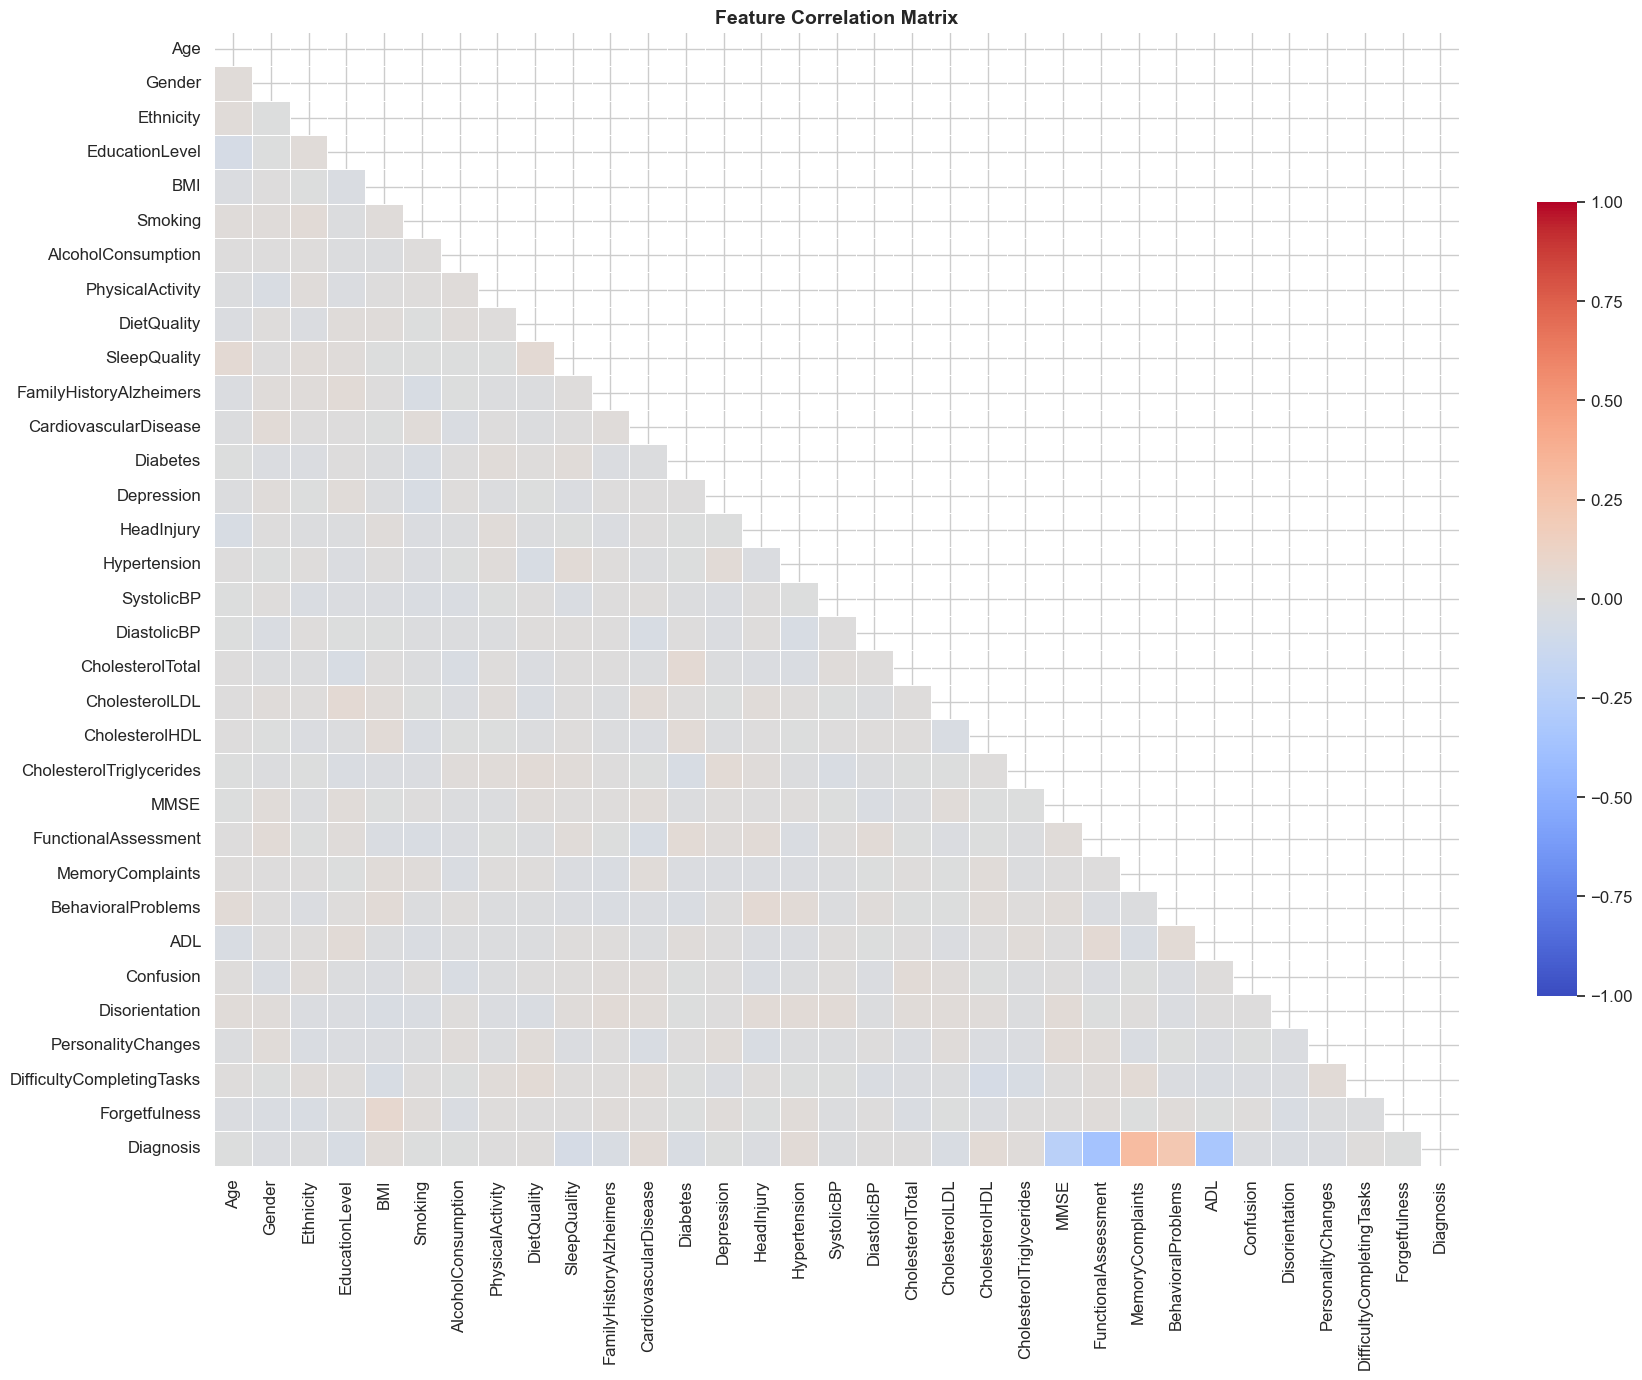

Top 10 features correlated with Diagnosis:
FunctionalAssessment       0.364898
ADL                        0.332346
MemoryComplaints           0.306742
MMSE                       0.237126
BehavioralProblems         0.224350
SleepQuality               0.056548
EducationLevel             0.043966
CholesterolHDL             0.042584
Hypertension               0.035080
FamilyHistoryAlzheimers    0.032900


In [10]:
feat_cols = [c for c in data.columns if c not in ['PatientID', 'DoctorInCharge']]
corr = data[feat_cols].corr()

fig, ax = plt.subplots(figsize=(18, 14))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, cmap='coolwarm', center=0,
    vmin=-1, vmax=1, annot=False, linewidths=0.4,
    cbar_kws={'shrink': 0.7}, ax=ax
)
ax.set_title('Feature Correlation Matrix', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

# Top correlations with Diagnosis
diag_corr = corr['Diagnosis'].drop('Diagnosis').abs().sort_values(ascending=False)
print('Top 10 features correlated with Diagnosis:')
print(diag_corr.head(10).to_string())

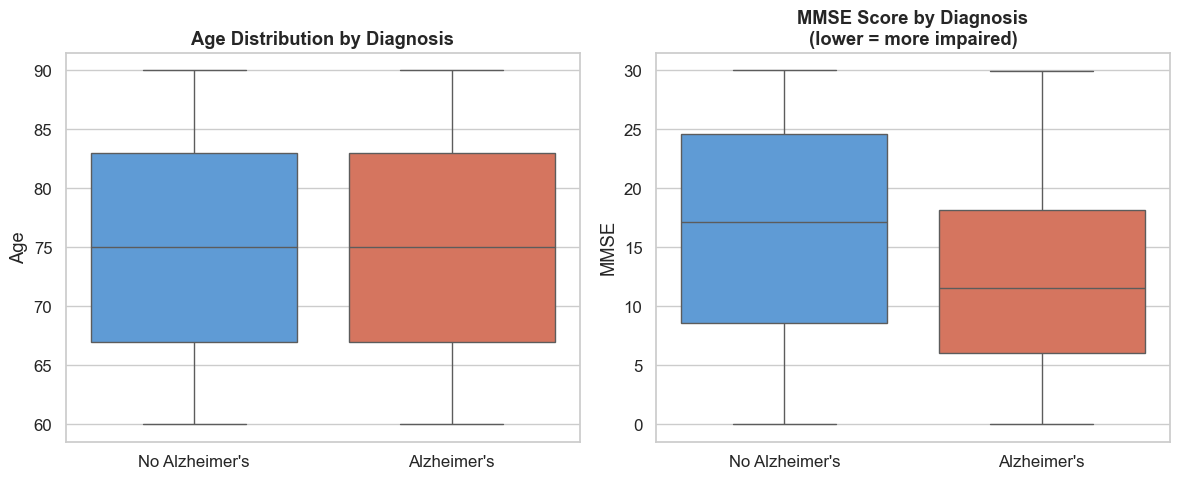

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, col, title in zip(axes,
                           ['Age', 'MMSE'],
                           ['Age Distribution by Diagnosis',
                            'MMSE Score by Diagnosis\n(lower = more impaired)']):
    data_plot = data[[col, 'Diagnosis']].copy()
    data_plot['Label'] = data_plot['Diagnosis'].map({0: "No Alzheimer's", 1: "Alzheimer's"})
    sns.boxplot(data=data_plot, x='Label', y=col,
                palette={"No Alzheimer's": COLORS[0], "Alzheimer's": COLORS[1]}, ax=ax)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

## Step 4: Prepare Data 

In [12]:
drop_cols = ['PatientID', 'DoctorInCharge']

clean_data = data.drop(columns=drop_cols).copy()
print(f"Data shape after dropping columns: {clean_data.shape}")

Data shape after dropping columns: (2149, 33)


In [13]:
TARGET = 'Diagnosis'
X = clean_data.drop(columns=[TARGET])
y = clean_data[TARGET]

FEATURE_NAMES = X.columns.tolist()
print(f'Features : {len(FEATURE_NAMES)}')
print(f'Samples  : {len(y):,}')
print(f'Positive class rate: {y.mean():.1%}')

Features : 32
Samples  : 2,149
Positive class rate: 35.4%


In [14]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f'Train      : {X_train.shape[0]:,} samples  ({y_train.mean():.1%} positive)')
print(f'Validation : {X_val.shape[0]:,} samples  ({y_val.mean():.1%} positive)')
print(f'Test       : {X_test.shape[0]:,} samples  ({y_test.mean():.1%} positive)')

Train      : 1,504 samples  (35.4% positive)
Validation : 322 samples  (35.4% positive)
Test       : 323 samples  (35.3% positive)


In [15]:
scaler = StandardScaler()
X_train_sc = pd.DataFrame(scaler.fit_transform(X_train), columns=FEATURE_NAMES)
X_val_sc   = pd.DataFrame(scaler.transform(X_val),   columns=FEATURE_NAMES)
X_test_sc  = pd.DataFrame(scaler.transform(X_test),  columns=FEATURE_NAMES)
print('Features standardized using StandardScaler.')

Features standardized using StandardScaler.


## Step 5: Train Models

In [16]:
def evaluate_model(name, model, X_eval, y_eval, threshold=0.5):
    proba = model.predict_proba(X_eval)[:, 1]
    y_pred = (proba >= threshold).astype(int)
    return {
        'Model' : name,
        'Accuracy' : accuracy_score(y_eval, y_pred),
        'Precision': precision_score(y_eval, y_pred),
        'Recall'   : recall_score(y_eval, y_pred),
        'F1 Score' : f1_score(y_eval, y_pred),
        'ROC-AUC'  : roc_auc_score(y_eval, proba)
    }

In [17]:
#Gradient Boost Model
print("Training Gradient Boosting...")
gb_base = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=4,
    min_samples_split=20,
    subsample=0.8,
    random_state=42
)

gb_base.fit(X_train, y_train)
print("Gradient Boosting trained.")
print("Roc-Auc:", roc_auc_score(y_val, gb_base.predict_proba(X_val)[:, 1]))

Training Gradient Boosting...
Gradient Boosting trained.
Roc-Auc: 0.9468623481781375


In [18]:
#Random Forest Model 
print('Training Random Forest...')
rf_base = RandomForestClassifier(
    n_estimators=300, max_depth=None,
    min_samples_split=10, max_features='sqrt',
    class_weight='balanced', random_state=42, n_jobs=-1
)
rf_base.fit(X_train, y_train)
print("Random Forest trained.")
print("Roc-Auc:", roc_auc_score(y_val, rf_base.predict_proba(X_val)[:, 1]))

Training Random Forest...
Random Forest trained.
Roc-Auc: 0.93459008097166


In [19]:
#XGBoost Model
print("Training XGBoost...")
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
xgb_base = xgb.XGBClassifier(
    n_estimators=300, learning_rate=0.05,
    max_depth=5, subsample=0.8,
    colsample_bytree=0.8, scale_pos_weight=scale_pos,
    eval_metric='logloss', use_label_encoder=False,
    random_state=42, n_jobs=-1
)
xgb_base.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)
print("XGBoost trained.")
print("Roc-Auc:", roc_auc_score(y_val, xgb_base.predict_proba(X_val)[:, 1]))

Training XGBoost...
XGBoost trained.
Roc-Auc: 0.938807354925776


In [20]:
#Base comparison between models
base_results = pd.DataFrame([
    evaluate_model('Gradient Boosting', gb_base,  X_val, y_val),
    evaluate_model('Random Forest',     rf_base,  X_val, y_val),
    evaluate_model('XGBoost',           xgb_base, X_val, y_val),
])

base_results_disp = base_results.set_index('Model').round(4)
print("=" * 65)
print('Base Performance/Results')
print("="*65)
print(base_results_disp.to_string())

Base Performance/Results
                   Accuracy  Precision  Recall  F1 Score  ROC-AUC
Model                                                            
Gradient Boosting    0.9472     0.9533  0.8947    0.9231   0.9469
Random Forest        0.9441     0.9706  0.8684    0.9167   0.9346
XGBoost              0.9472     0.9533  0.8947    0.9231   0.9388


## Step 7: Fine-Tune the Models

In [21]:
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
N_ITER = 30   # increase for a more exhaustive search

In [22]:
# Tuning Gradient Boosting
gb_param_dist = {
    'n_estimators'    : [100, 200, 300, 500],
    'learning_rate'   : [0.01, 0.05, 0.1, 0.2],
    'max_depth'       : [3, 4, 5, 6],
    'min_samples_split': [10, 20, 30],
    'subsample'       : [0.6, 0.8, 1.0],
    'max_features'    : ['sqrt', 'log2', None],
}

gb_search = RandomizedSearchCV(
    GradientBoostingClassifier(random_state=42),
    gb_param_dist, n_iter=N_ITER, scoring='roc_auc',
    cv=CV, random_state=42, n_jobs=-1, verbose=0
)
gb_search.fit(X_train, y_train)
gb_tuned = gb_search.best_estimator_

print('Best GB params:', gb_search.best_params_)
print('Best CV AUC   :', round(gb_search.best_score_, 4))

Best GB params: {'subsample': 1.0, 'n_estimators': 300, 'min_samples_split': 20, 'max_features': 'sqrt', 'max_depth': 6, 'learning_rate': 0.01}
Best CV AUC   : 0.9541


In [23]:
# Tuning Random Forest
rf_param_dist = {
    'n_estimators'    : [200, 300, 500],
    'max_depth'       : [None, 10, 20, 30],
    'min_samples_split': [5, 10, 20],
    'min_samples_leaf': [1, 2, 4],
    'max_features'    : ['sqrt', 'log2'],
    'class_weight'    : ['balanced', 'balanced_subsample', None],
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    rf_param_dist, n_iter=N_ITER, scoring='roc_auc',
    cv=CV, random_state=42, n_jobs=-1, verbose=0
)
rf_search.fit(X_train, y_train)
rf_tuned = rf_search.best_estimator_

print('Best RF params:', rf_search.best_params_)
print('Best CV AUC   :', round(rf_search.best_score_, 4))

Best RF params: {'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 20, 'class_weight': 'balanced_subsample'}
Best CV AUC   : 0.9545


In [24]:
# Tuning XGBoost
xgb_param_dist = {
    'n_estimators'   : [200, 300, 500],
    'learning_rate'  : [0.01, 0.05, 0.1],
    'max_depth'      : [3, 4, 5, 6],
    'subsample'      : [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma'          : [0, 0.1, 0.5, 1],
    'reg_alpha'      : [0, 0.1, 1],
    'reg_lambda'     : [1, 2, 5],
}

xgb_search = RandomizedSearchCV(
    xgb.XGBClassifier(
        scale_pos_weight=scale_pos,
        eval_metric='logloss', use_label_encoder=False,
        random_state=42, n_jobs=-1
    ),
    xgb_param_dist, n_iter=N_ITER, scoring='roc_auc',
    cv=CV, random_state=42, n_jobs=-1, verbose=0
)
xgb_search.fit(X_train, y_train)
xgb_tuned = xgb_search.best_estimator_

print('Best XGB params:', xgb_search.best_params_)
print('Best CV AUC    :', round(xgb_search.best_score_, 4))

Best XGB params: {'subsample': 0.8, 'reg_lambda': 1, 'reg_alpha': 0.1, 'n_estimators': 500, 'max_depth': 5, 'learning_rate': 0.1, 'gamma': 0.1, 'colsample_bytree': 0.8}
Best CV AUC    : 0.9556


In [25]:
tuned_results = pd.DataFrame([
    evaluate_model('Gradient Boosting (tuned)', gb_tuned,  X_val, y_val),
    evaluate_model('Random Forest (tuned)',     rf_tuned,  X_val, y_val),
    evaluate_model('XGBoost (tuned)',           xgb_tuned, X_val, y_val),
])

comparison = pd.concat([
    base_results.assign(Stage='Baseline'),
    tuned_results.assign(Stage='Tuned')
])

pivot = (comparison.pivot_table(values='ROC-AUC', index='Stage', columns='Model')
         .round(4))
print("=" * 65)
print(' ROC-AUC: Baseline vs Tuned Models ')
print("=" * 65)
print(pivot.to_string())

 ROC-AUC: Baseline vs Tuned Models 
Model     Gradient Boosting  Gradient Boosting (tuned)  Random Forest  Random Forest (tuned)  XGBoost  XGBoost (tuned)
Stage                                                                                                                 
Baseline             0.9469                        NaN         0.9346                    NaN   0.9388              NaN
Tuned                   NaN                     0.9383            NaN                 0.9363      NaN            0.935


## Step 8: Evaluations

In [26]:
MODELS = {
    'Gradient Boosting': gb_tuned,
    'Random Forest'    : rf_tuned,
    'XGBoost'          : xgb_tuned,
}

test_results = pd.DataFrame([
    evaluate_model(name, model, X_test, y_test)
    for name, model in MODELS.items()
])

print('═'*65)
print('      FINAL TEST SET PERFORMANCE (Tuned Models)      ')
print('═'*65)
print(test_results.set_index('Model').round(4).to_string())

═════════════════════════════════════════════════════════════════
      FINAL TEST SET PERFORMANCE (Tuned Models)      
═════════════════════════════════════════════════════════════════
                   Accuracy  Precision  Recall  F1 Score  ROC-AUC
Model                                                            
Gradient Boosting    0.9536     0.9304  0.9386    0.9345   0.9607
Random Forest        0.9474     0.9217  0.9298    0.9258   0.9518
XGBoost              0.9505     0.9224  0.9386    0.9304   0.9555


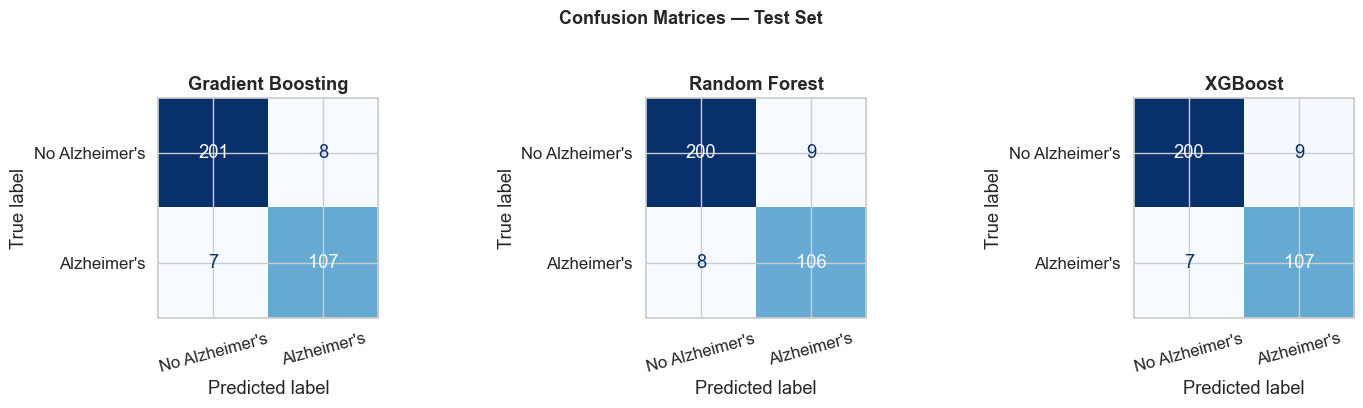

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, model) in zip(axes, MODELS.items()):
    preds = model.predict(X_test)
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=["No Alzheimer's", "Alzheimer's"])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontweight='bold')
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Confusion Matrices — Test Set', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [28]:
for name, model in MODELS.items():
    print(f'═══ {name} ═══')
    print(classification_report(y_test, model.predict(X_test),
                                target_names=["No Alzheimer's", "Alzheimer's"]))

═══ Gradient Boosting ═══
                precision    recall  f1-score   support

No Alzheimer's       0.97      0.96      0.96       209
   Alzheimer's       0.93      0.94      0.93       114

      accuracy                           0.95       323
     macro avg       0.95      0.95      0.95       323
  weighted avg       0.95      0.95      0.95       323

═══ Random Forest ═══
                precision    recall  f1-score   support

No Alzheimer's       0.96      0.96      0.96       209
   Alzheimer's       0.92      0.93      0.93       114

      accuracy                           0.95       323
     macro avg       0.94      0.94      0.94       323
  weighted avg       0.95      0.95      0.95       323

═══ XGBoost ═══
                precision    recall  f1-score   support

No Alzheimer's       0.97      0.96      0.96       209
   Alzheimer's       0.92      0.94      0.93       114

      accuracy                           0.95       323
     macro avg       0.94      0

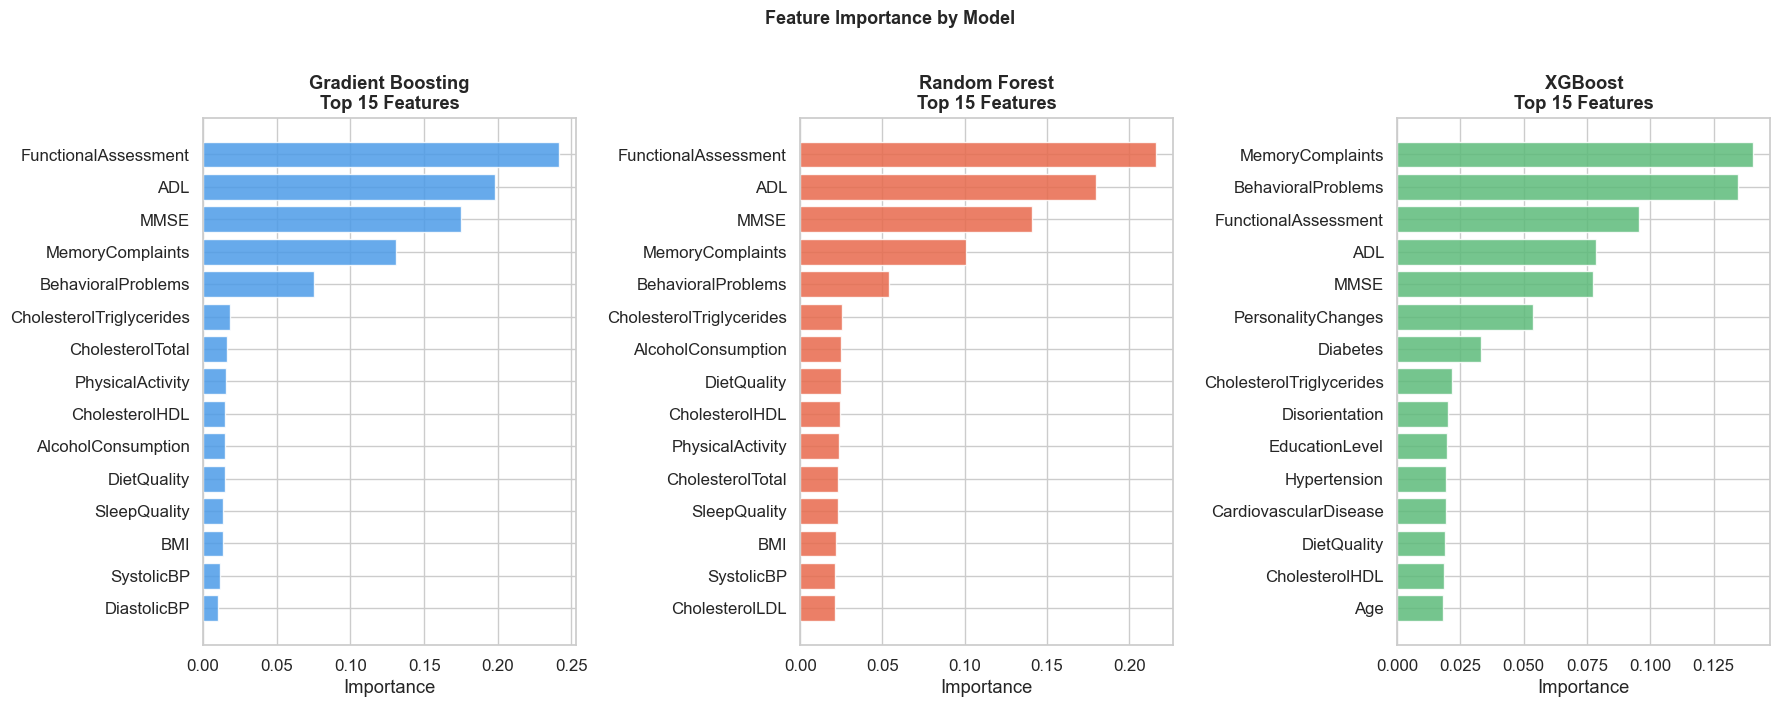

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
TOP_N = 15

for ax, (name, model), color in zip(axes, MODELS.items(), COLORS):
    if hasattr(model, 'feature_importances_'):
        importances = pd.Series(model.feature_importances_, index=FEATURE_NAMES)
    else:
        importances = pd.Series(
            permutation_importance(model, X_test, y_test, n_repeats=10,
                                   random_state=42).importances_mean,
            index=FEATURE_NAMES
        )
    top = importances.sort_values(ascending=True).tail(TOP_N)
    ax.barh(top.index, top.values, color=color, alpha=0.85)
    ax.set_title(f'{name}\nTop {TOP_N} Features', fontweight='bold')
    ax.set_xlabel('Importance')

plt.suptitle('Feature Importance by Model', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Step 9: Cross-Validation

In [30]:
from sklearn.model_selection import cross_validate
import pandas as pd

X_cv = pd.concat([X_train, X_val])
y_cv = pd.concat([y_train, y_val])

CV10 = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

cv_rows = []
for name, model in MODELS.items():
    scores = cross_validate(
        model, X_cv, y_cv,
        cv=CV10,
        scoring=['accuracy', 'roc_auc'],
        n_jobs=-1
    )
    cv_rows.append({
        'Model'           : name,
        'CV Accuracy Mean': scores['test_accuracy'].mean(),
        'CV Accuracy Std' : scores['test_accuracy'].std(),
        'CV AUC Mean'     : scores['test_roc_auc'].mean(),
        'CV AUC Std'      : scores['test_roc_auc'].std(),
    })

cv_df = pd.DataFrame(cv_rows).set_index('Model').round(4)
print('── Fold Stratified Cross-Validation (train + val pool) ──────────')
print(cv_df.to_string())

── Fold Stratified Cross-Validation (train + val pool) ──────────
                   CV Accuracy Mean  CV Accuracy Std  CV AUC Mean  CV AUC Std
Model                                                                        
Gradient Boosting            0.9447           0.0199       0.9491      0.0245
Random Forest                0.9507           0.0195       0.9505      0.0250
XGBoost                      0.9485           0.0179       0.9518      0.0234


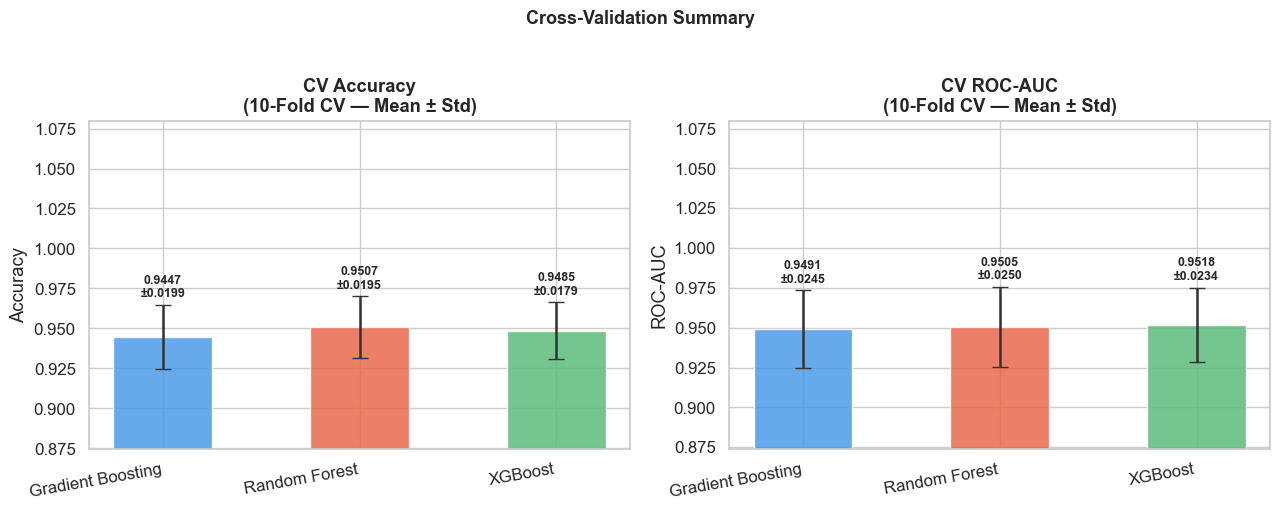

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

model_names = cv_df.index.tolist()
x = np.arange(len(model_names))

for ax, metric, mean_col, std_col, ylabel in zip(
    axes,
    ['CV Accuracy', 'CV ROC-AUC'],
    ['CV Accuracy Mean', 'CV AUC Mean'],
    ['CV Accuracy Std',  'CV AUC Std'],
    ['Accuracy', 'ROC-AUC']
):
    means = cv_df[mean_col].values
    stds  = cv_df[std_col].values

    bars = ax.bar(x, means, color=COLORS[:3], alpha=0.85,
                  yerr=stds, capsize=6, edgecolor='white', width=0.5,
                  error_kw=dict(elinewidth=1.8, ecolor='#333333'))

    for bar, m, s in zip(bars, means, stds):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + s + 0.003,
                f'{m:.4f}\n\u00b1{s:.4f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels(model_names, rotation=10, ha='right')
    ax.set_ylabel(ylabel)
    ax.set_title(f'{metric}\n(10-Fold CV — Mean ± Std)', fontweight='bold')
    low = max(0, means.min() - stds.max() - 0.05)
    ax.set_ylim(low, 1.08)

plt.suptitle('Cross-Validation Summary', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Step 10: Save Models

In [34]:
from joblib import dump

xgb_tuned.save_model('xgb_alzheimers_model.json')
dump(rf_tuned, 'rf_alzheimers_model.joblib')
dump(gb_tuned, 'gb_alzheimers_model.joblib')

['gb_alzheimers_model.joblib']